In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

In [ ]:
arquivo = files.upload()


Saving palma_muda.png to palma_muda (1).png


array([[255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255],
       ...,
       [255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255]], dtype=uint8)
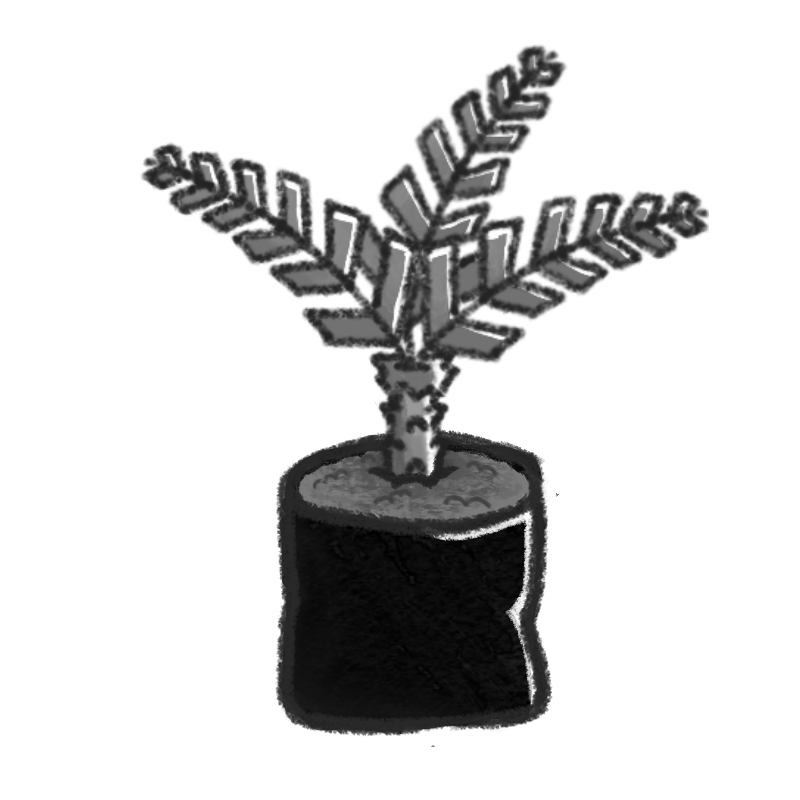

In [ ]:
# Obtém o nome do arquivo enviado e carrega a imagem
nome_arquivo = next(iter(arquivo))
img_bgr = cv2.imread(nome_arquivo)
img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
img_gray

## Resposta

À medida que reduzimos o número de bits, a quantidade de níveis de intensidade disponíveis também diminui. Com isso, detalhes sutis da imagem são perdidos e as transições entre tons ficam mais bruscas, podendo aparecer regiões com aparência de faixas (posterização). Em 1 bit, a imagem possui apenas preto e branco; conforme aumentamos para 2, 4 e 8 bits, mais níveis são recuperados e as transições de intensidade ficam progressivamente mais suaves, com 8 bits preservando praticamente todos os detalhes de intensidade da imagem em tons de cinza.


In [ ]:
# Quantização da imagem em tons de cinza
# A quantização é feita diretamente sobre os valores dos pixels usando NumPy.

def quantizar(imagem, bits):
    niveis = 2 ** bits
    passo = 256 / niveis

    # Determina o nível de quantização de cada pixel.
    indice = np.floor(imagem / passo)

    # Mapeia os índices para a faixa 0–255.
    quantizada = indice * (255 / (niveis - 1))

    return np.clip(quantizada, 0, 255).astype(np.uint8)




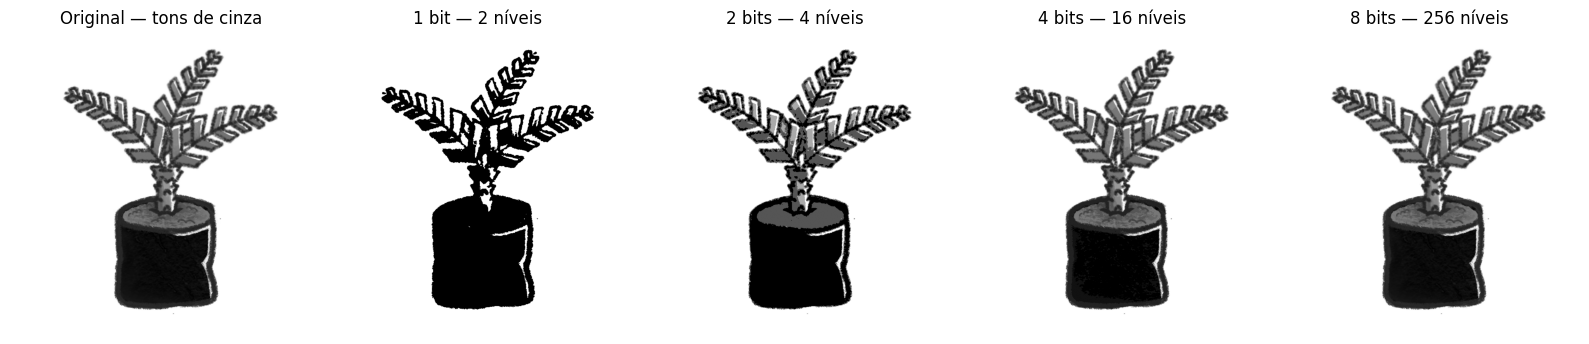

In [ ]:
img_1bit = quantizar(img_gray, 1)
img_2bit = quantizar(img_gray, 2)
img_4bit = quantizar(img_gray, 4)
img_8bit = quantizar(img_gray, 8)

fig, ax = plt.subplots(1, 5, figsize=(16, 4))

ax[0].imshow(img_gray, cmap="gray", vmin=0, vmax=255)
ax[0].set_title("Original — tons de cinza")
ax[0].axis("off")

ax[1].imshow(img_1bit, cmap="gray", vmin=0, vmax=255)
ax[1].set_title("1 bit — 2 níveis")
ax[1].axis("off")

ax[2].imshow(img_2bit, cmap="gray", vmin=0, vmax=255)
ax[2].set_title("2 bits — 4 níveis")
ax[2].axis("off")

ax[3].imshow(img_4bit, cmap="gray", vmin=0, vmax=255)
ax[3].set_title("4 bits — 16 níveis")
ax[3].axis("off")

ax[4].imshow(img_8bit, cmap="gray", vmin=0, vmax=255)
ax[4].set_title("8 bits — 256 níveis")
ax[4].axis("off")

plt.tight_layout()
plt.savefig("quantizacao.png", dpi=300, bbox_inches="tight")
plt.show()
